In [1]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


**Generar Dataset Inteligente**

In [2]:
import random
import numpy as np

# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

empleados = []

for i in range(300):

    edad = random.randint(22, 60)

    anios_empresa = random.randint(
        0,
        min(20, edad - 22)
    )

    salario_mensual = random.randint(500, 4000)

    horas_extra_semana = random.randint(0, 20)

    satisfaccion_laboral = random.randint(1, 5)

    num_proyectos_anio = random.randint(1, 10)

    distancia_casa_trabajo_km = random.randint(1, 80)

    ultima_evaluacion_desempenio = round(
        random.uniform(0.4, 1.0), 2
    )

    capacitaciones_recibidas = random.randint(0, 5)

    tiene_ascenso_ultimos_2_anios = random.randint(0, 1)

    # -------------------------
    # Lógica de renuncia
    # -------------------------

    probabilidad = 0.10

    if satisfaccion_laboral <= 2:
        probabilidad += 0.30

    if horas_extra_semana > 15:
        probabilidad += 0.20

    if tiene_ascenso_ultimos_2_anios == 0:
        probabilidad += 0.10

    if distancia_casa_trabajo_km > 40:
        probabilidad += 0.10

    if salario_mensual < 1000:
        probabilidad += 0.15

    if satisfaccion_laboral >= 4:
        probabilidad -= 0.20

    if tiene_ascenso_ultimos_2_anios == 1:
        probabilidad -= 0.10

    probabilidad = max(0, min(probabilidad, 0.95))

    renuncia = 1 if random.random() < probabilidad else 0

    empleados.append([
        edad,
        anios_empresa,
        salario_mensual,
        horas_extra_semana,
        satisfaccion_laboral,
        num_proyectos_anio,
        distancia_casa_trabajo_km,
        ultima_evaluacion_desempenio,
        capacitaciones_recibidas,
        tiene_ascenso_ultimos_2_anios,
        renuncia
    ])

**Crear DataFrame + Guardar CSV + Verificar tamaño**

In [3]:
columnas = [
    "edad",
    "anios_en_empresa",
    "salario_mensual",
    "horas_extra_semana",
    "satisfaccion_laboral",
    "num_proyectos_anio",
    "distancia_casa_trabajo_km",
    "ultima_evaluacion_desempenio",
    "capacitaciones_recibidas",
    "tiene_ascenso_ultimos_2_anios",
    "renuncia"
]

df = pd.DataFrame(
    empleados,
    columns=columnas
)

df.head()

df.to_csv(
    "empleados.csv",
    index=False
)

print("Dataset guardado correctamente")

df.shape


Dataset guardado correctamente


(300, 11)

**Análisis Exploratorio (EDA)**
1. Calcula y muestra estadísticas descriptivas completas del dataset (media, std, min, max,
percentiles).
2. Genera un heatmap de correlación entre todas las variables numéricas. Identifica las 3
correlaciones más fuertes con la variable objetivo.
3. Grafica la distribución de la variable renuncia. ¿Está balanceado el dataset? Si no, documenta
qué harás al respecto.
4. Genera boxplots de salario_mensual y satisfaccion_laboral separados por la variable renuncia.
¿Qué patrones observas?

**Estadísticas descriptivas**

In [4]:
df.describe()

,edad,anios_en_empresa,salario_mensual,horas_extra_semana,satisfaccion_laboral,num_proyectos_anio,distancia_casa_trabajo_km,ultima_evaluacion_desempenio,capacitaciones_recibidas,tiene_ascenso_ultimos_2_anios,renuncia
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,42.136667,8.270000,2210.370000,10.470000,3.056667,5.483333,43.516667,0.706767,2.623333,0.493333,0.300000
std,10.669777,5.829555,997.135358,6.315752,1.435383,2.744966,21.642343,0.174589,1.782896,0.500791,0.459023
min,22.000000,0.000000,514.000000,0.000000,1.000000,1.000000,3.000000,0.410000,0.000000,0.000000,0.000000
25%,33.750000,3.000000,1328.750000,5.000000,2.000000,3.000000,25.000000,0.560000,1.000000,0.000000,0.000000
50%,42.000000,7.500000,2288.000000,10.000000,3.000000,5.000000,45.000000,0.720000,3.000000,0.000000,0.000000
75%,51.250000,14.000000,3017.750000,17.000000,4.000000,8.000000,61.000000,0.850000,4.000000,1.000000,1.000000
max,60.000000,20.000000,3987.000000,20.000000,5.000000,10.000000,80.000000,1.000000,5.000000,1.000000,1.000000


**Heatmap de correlación**

Genera un heatmap de correlación entre todas las variables numéricas. 

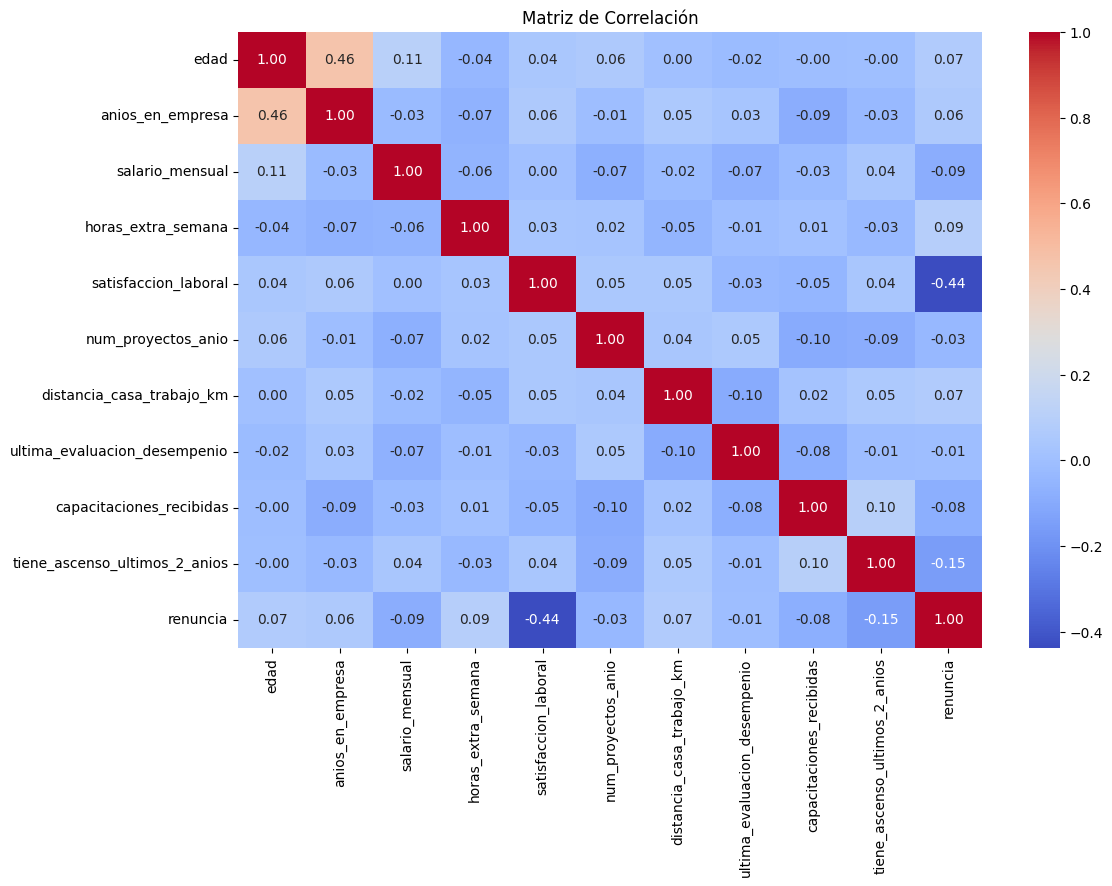

In [5]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación")
plt.show()

In [30]:
correlaciones = df.corr()["renuncia"]

correlaciones.sort_values(
    ascending=False
)

renuncia                         1.000000
horas_extra_semana               0.091945
edad                             0.072862
distancia_casa_trabajo_km        0.068510
anios_en_empresa                 0.057118
ultima_evaluacion_desempenio    -0.006635
num_proyectos_anio              -0.033179
capacitaciones_recibidas        -0.082142
salario_mensual                 -0.087168
tiene_ascenso_ultimos_2_anios   -0.151311
satisfaccion_laboral            -0.437048
Name: renuncia, dtype: float64

**Identificación de las 3 correlaciones más fuertes con la variable objetivo**

Las variables con mayor relación respecto a la renuncia fueron:

- Satisfacción laboral.
- Ascensos recibidos en los últimos 2 años.
- Horas extra trabajadas por semana.

La satisfacción laboral presenta la correlación más fuerte y negativa, indicando que los empleados más satisfechos tienen menor probabilidad de renunciar. Por otro lado, las horas extra muestran una correlación positiva, sugiriendo que una mayor carga de trabajo puede aumentar la probabilidad de renuncia.

**Distribución de renuncias**

Grafica la distribución de la variable renuncia. ¿Está balanceado el dataset? Si no, documenta
qué harás al respecto.

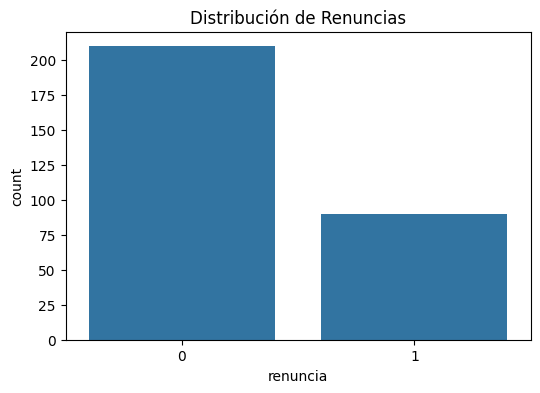

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="renuncia",
    data=df
)

plt.title("Distribución de Renuncias")
plt.show()

**Cantidad exacta de clases**

In [32]:
df["renuncia"].value_counts()
df["renuncia"].value_counts(normalize=True) * 100

renuncia
0    70.0
1    30.0
Name: proportion, dtype: float64

**Distribución de la Variable Objetivo**

La distribución de la variable renuncia muestra que el 70% de los empleados permanecieron en la empresa, mientras que el 30% renunciaron.

Aunque existe un ligero desbalance entre las clases, este no es lo suficientemente severo como para requerir técnicas de balanceo adicionales. Por lo tanto, se procede con el entrenamiento de los modelos utilizando la distribución original de los datos.

**Boxplot**

Genera boxplots de salario_mensual y satisfaccion_laboral separados por la variable renuncia.

¿Qué patrones se observa?

**Boxplot de Salario vs Renuncia**

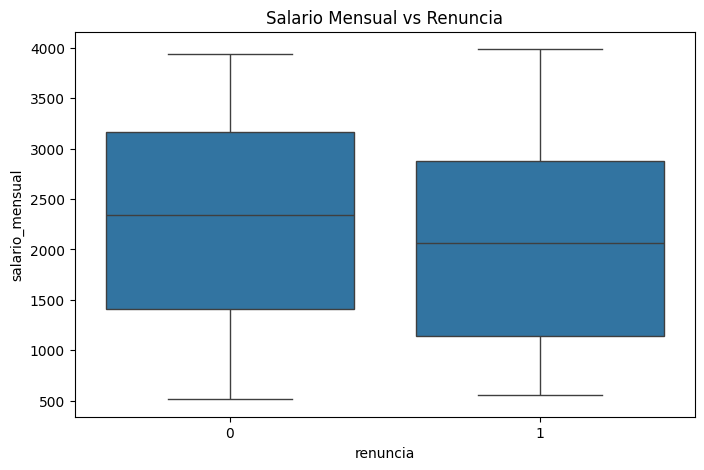

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="renuncia",
    y="salario_mensual",
    data=df
)

plt.title("Salario Mensual vs Renuncia")
plt.show()

**Boxplot de Satisfacción Laboral vs Renuncia**

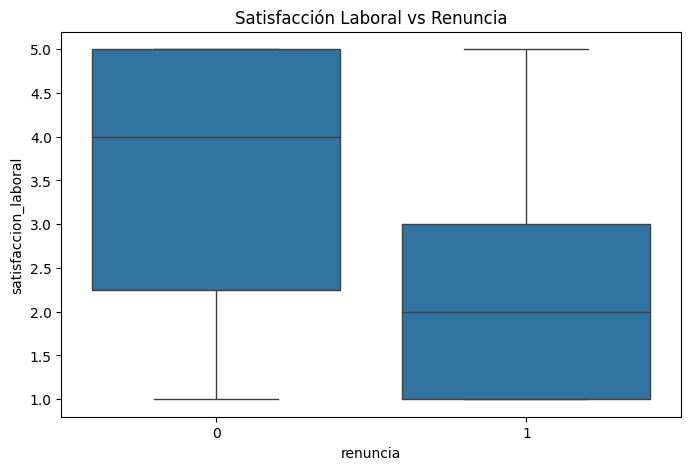

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="renuncia",
    y="satisfaccion_laboral",
    data=df
)

plt.title("Satisfacción Laboral vs Renuncia")
plt.show()

**Hallazgos del EDA**

Los boxplots facilitan la comparación entre los empleados que renuncian a su puesto y los que continúan en la empresa.

Los empleados con menor satisfacción laboral muestran una mayor tendencia a renunciar. También, los niveles salariales presentan diferencias entre ambos grupos, lo que indica que la compensación económica puede influir en la decisión de permanencia de los empleados.



# Preparación de Datos

**Definir X e Y**

In [35]:
X = df.drop("renuncia", axis=1)

y = df["renuncia"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (300, 10)
Variable objetivo: (300,)


**Train/Test Split**

Dividir el dataset: 80% entrenamiento, 20% prueba. Usar random_state=42

Estandarizar features numéricas con StandardScaler (ajustar SOLO sobre train).

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (240, 10)
Prueba: (60, 10)


**Escalado de Datos**

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Modelo 1: Regresión Logística**

Se entrena un modelo de Regresión Logística para predecir la probabilidad de renuncia de los empleados.

In [40]:
modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(
    X_train_scaled,
    y_train
)

pred_lr = modelo_lr.predict(
    X_test_scaled
)

prob_lr = modelo_lr.predict_proba(
    X_test_scaled
)[:,1]

**Métricas Regresión Logística**

In [39]:
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))
print("AUC ROC:", roc_auc_score(y_test, prob_lr))

Accuracy: 0.7666666666666667
Precision: 0.6666666666666666
Recall: 0.4444444444444444
F1 Score: 0.5333333333333333
AUC ROC: 0.8108465608465608


**Modelo 2: Random Forest**

Se entrena un modelo Random Forest para capturar relaciones más complejas entre las variables del dataset.

In [41]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(
    X_train,
    y_train
)

pred_rf = modelo_rf.predict(X_test)

prob_rf = modelo_rf.predict_proba(X_test)[:,1]

**Métricas Random Forest**

In [42]:
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))
print("AUC ROC:", roc_auc_score(y_test, prob_rf))

Accuracy: 0.7333333333333333
Precision: 0.5714285714285714
Recall: 0.4444444444444444
F1 Score: 0.5
AUC ROC: 0.7552910052910053


**Modelo 3: Gradient Boosting**

Se entrena un modelo Gradient Boosting para mejorar la capacidad predictiva mediante el aprendizaje secuencial de errores.

In [43]:
modelo_gb = GradientBoostingClassifier(
    random_state=42
)

modelo_gb.fit(
    X_train,
    y_train
)

pred_gb = modelo_gb.predict(X_test)

prob_gb = modelo_gb.predict_proba(X_test)[:,1]

**Métricas Gradient Boosting**

In [44]:
print("Accuracy:", accuracy_score(y_test, pred_gb))
print("Precision:", precision_score(y_test, pred_gb))
print("Recall:", recall_score(y_test, pred_gb))
print("F1 Score:", f1_score(y_test, pred_gb))
print("AUC ROC:", roc_auc_score(y_test, prob_gb))

Accuracy: 0.6666666666666666
Precision: 0.4375
Recall: 0.3888888888888889
F1 Score: 0.4117647058823529
AUC ROC: 0.6653439153439153


**Tabla Comparativa**

In [45]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_gb)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_gb)
    ],
    "F1": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_gb)
    ],
    "AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_rf),
        roc_auc_score(y_test, prob_gb)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,0.766667,0.666667,0.444444,0.533333,0.810847
1,Random Forest,0.733333,0.571429,0.444444,0.500000,0.755291
2,Gradient Boosting,0.666667,0.437500,0.388889,0.411765,0.665344


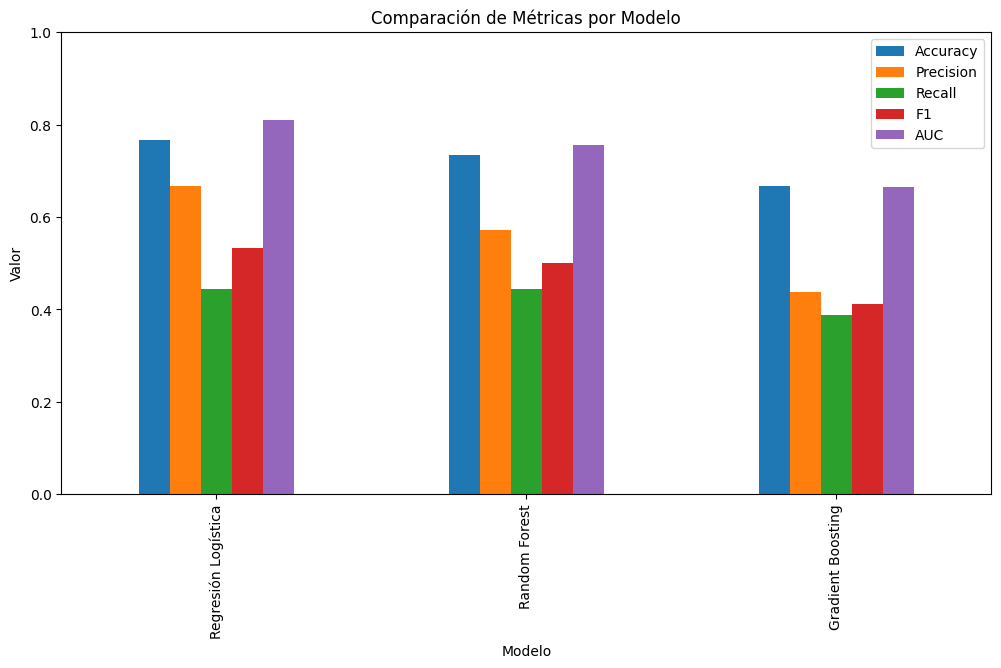

In [46]:
resultados.set_index("Modelo").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparación de Métricas por Modelo")
plt.ylabel("Valor")
plt.ylim(0,1)

plt.show()

**Interpretación de los Resultados**

Se entrenaron tres modelos de clasificación para predecir la renuncia de empleados: Regresión Logística, Random Forest y Gradient Boosting.

Los resultados muestran que la Regresión Logística obtuvo el mejor desempeño general, alcanzando una exactitud (Accuracy) de 76.67%, una precisión (Precision) de 66.67% y el mayor valor de AUC-ROC (0.8108).

Random Forest presentó un desempeño intermedio, con una exactitud de 73.33% y un AUC-ROC de 0.7553.

Por su parte, Gradient Boosting obtuvo los resultados más bajos entre los tres modelos evaluados, con una exactitud de 66.67% y un AUC-ROC de 0.6653.

Considerando todas las métricas evaluadas, la Regresión Logística se selecciona como el mejor modelo para este problema de clasificación.

# Matrices de Confusión

Graficar la matriz de confusión de cada modelo.

Las matrices de confusión permiten analizar el desempeño de los modelos identificando correctamente las predicciones verdaderas y los errores de clasificación.

**Matriz Regresión Logística**

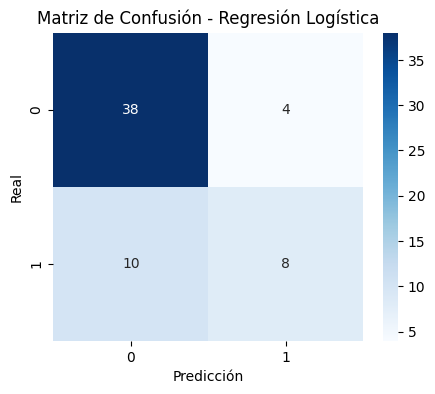

In [47]:
cm_lr = confusion_matrix(
    y_test,
    pred_lr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

**Matriz Random Forest**

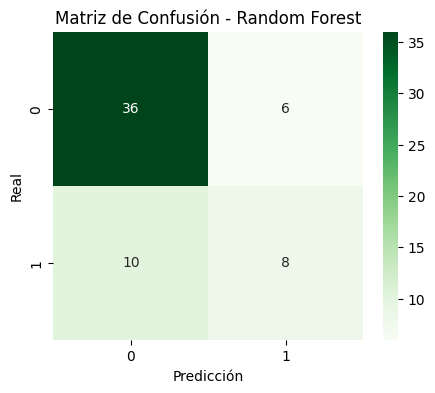

In [48]:
cm_rf = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

**Matriz Gradient Boosting**

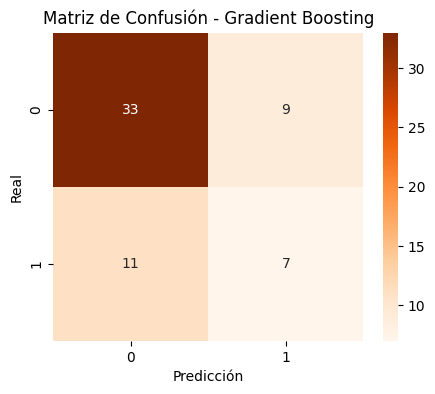

In [50]:
cm_gb = confusion_matrix(
    y_test,
    pred_gb
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Matriz de Confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

**Interpretación de las Matrices de Confusión**

La Regresión Logística presentó el mejor desempeño general, logrando clasificar correctamente 46 de los 60 registros del conjunto de prueba (38 empleados que permanecieron y 8 que renunciaron).

Random Forest obtuvo resultados similares, aunque generó un mayor número de falsos positivos.

Gradient Boosting presentó el desempeño más bajo, con una menor cantidad de predicciones correctas y un mayor número de errores de clasificación.

Estos resultados coinciden con las métricas de Accuracy, F1-Score y AUC-ROC, donde la Regresión Logística obtuvo los mejores valores generales.

Curva ROC

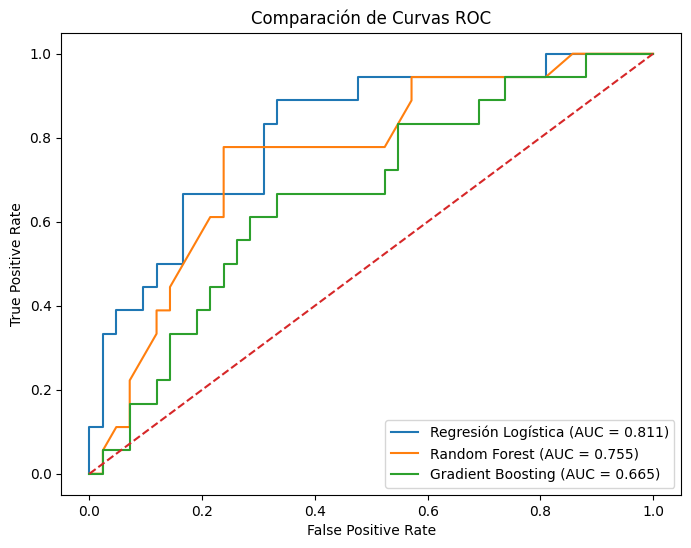

In [54]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, prob_gb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Regresión Logística (AUC = {:.3f})".format(
        roc_auc_score(y_test, prob_lr)
    )
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = {:.3f})".format(
        roc_auc_score(y_test, prob_rf)
    )
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label="Gradient Boosting (AUC = {:.3f})".format(
        roc_auc_score(y_test, prob_gb)
    )
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Comparación de Curvas ROC")

plt.legend()

plt.show()

**Comparación de Curvas ROC**

Las curvas ROC permiten evaluar la capacidad de los modelos para distinguir entre empleados que renuncian y aquellos que permanecen en la empresa.

La Regresión Logística presentó el mejor desempeño, obteniendo un AUC-ROC de 0.811 y mostrando una curva más alejada de la diagonal de referencia. Esto indica una mejor capacidad para diferenciar entre ambas clases.

Random Forest alcanzó un AUC-ROC de 0.755, mostrando un rendimiento aceptable aunque inferior al de la Regresión Logística.

Gradient Boosting obtuvo un AUC-ROC de 0.665, siendo el modelo con menor capacidad discriminativa entre los tres evaluados.

En consecuencia, la Regresión Logística se selecciona como el mejor modelo para este conjunto de datos.

# Para Random Forest y Gradient Boosting: graficar feature importance.

**Random Forest - Feature Importance**

Se analiza la importancia de las variables utilizando el modelo Random Forest para identificar los factores que más contribuyen a la predicción de la renuncia.

In [57]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

display(importancias_rf)

,Variable,Importancia
4,satisfaccion_laboral,0.185378
2,salario_mensual,0.120109
0,edad,0.116697
1,anios_en_empresa,0.110615
6,distancia_casa_trabajo_km,0.105780
7,ultima_evaluacion_desempenio,0.099714
3,horas_extra_semana,0.095547
8,capacitaciones_recibidas,0.071676
5,num_proyectos_anio,0.070439
9,tiene_ascenso_ultimos_2_anios,0.024046


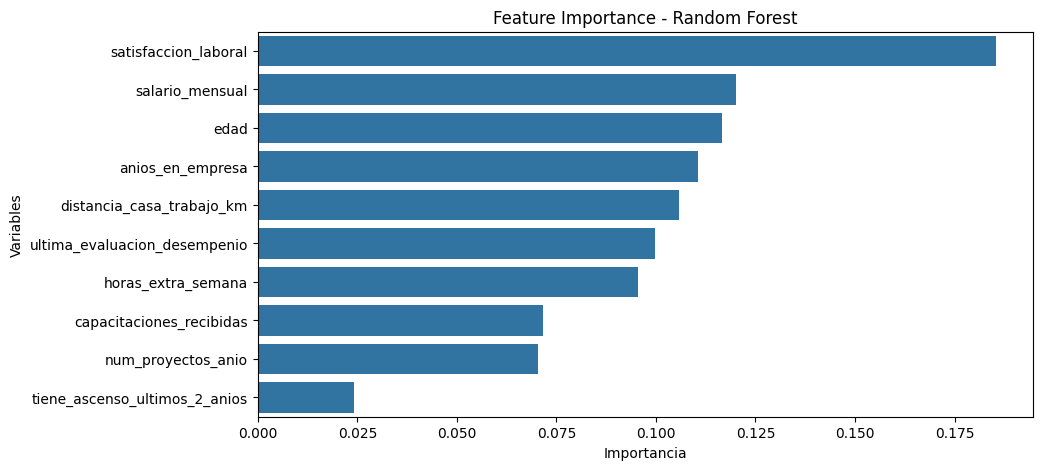

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancias_rf
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.show()

El modelo de Random Forest destaca la satisfaccion_laboral como el predictor principal. . Este resultado es consistente con una lógica organizacional donde el bienestar emocional del colaborador es el factor que más peso tiene al predecir una deserción. Otros factores como la edad y anios_en_empresa actúan como predictores secundarios, confirmando que el ciclo de vida del empleado en la compañía es un componente esencial para el modelo.

**Gradient Boosting - Feature Importance**

In [60]:
importancias_gb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_gb.feature_importances_
})

importancias_gb = importancias_gb.sort_values(
    by="Importancia",
    ascending=False
)

importancias_gb

,Variable,Importancia
4,satisfaccion_laboral,0.238685
7,ultima_evaluacion_desempenio,0.159929
2,salario_mensual,0.145700
0,edad,0.101546
6,distancia_casa_trabajo_km,0.100026
1,anios_en_empresa,0.095536
3,horas_extra_semana,0.072777
8,capacitaciones_recibidas,0.046035
9,tiene_ascenso_ultimos_2_anios,0.020297
5,num_proyectos_anio,0.019470


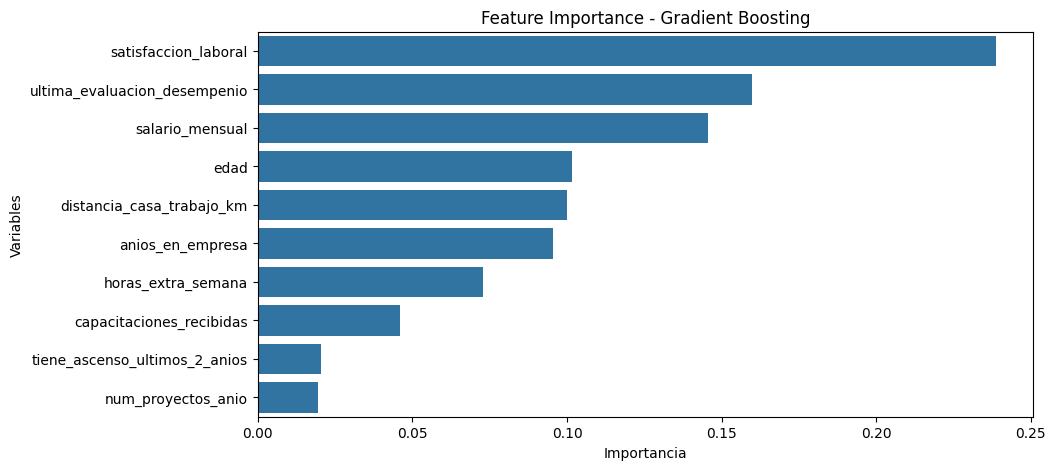

In [61]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancias_gb
)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.show()

Al observar la importancia de variables en Gradient Boosting, se aprecia una distribución de pesos ligeramente distinta. . Aunque la satisfaccion_laboral sigue siendo relevante, este algoritmo otorga un mayor peso a variables dinámicas como horas_extra_semana o ultima_evaluacion_desempeño. Esta diferencia es técnica y valiosa: mientras Random Forest busca patrones generales, el Gradient Boosting (al construir árboles de forma secuencial) logra detectar correlaciones más finas entre el rendimiento y la sobrecarga laboral.

## Optimización con Cross-Validation

**Validación Cruzada (K-Fold) - Regresión Logística**

Dado que la Regresión Logística fue el modelo con mejor desempeño (mayor F1-score y AUC), se aplicó validación cruzada con k = 5.

Este procedimiento permite evaluar la estabilidad del modelo dividiendo los datos en 5 subconjuntos y entrenando el modelo en diferentes combinaciones.

Se utiliza el F1-score como métrica principal, ya que permite balancear precisión y recall.

Se reporta el promedio y la desviación estándar del F1-score.

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

modelo_cv = LogisticRegression(random_state=42)

scores_f1 = cross_val_score(
    modelo_cv,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1-Score por Fold:")
print(scores_f1)

print("\nMedia F1:", scores_f1.mean())
print("Desviación Estándar:", scores_f1.std())

F1-Score por Fold:
[0.5        0.47619048 0.57142857 0.57142857 0.28571429]

Media F1: 0.48095238095238085
Desviación Estándar: 0.10476190476190476


El F1-Score promedio obtenido fue de 0.4810, con una desviación estándar de 0.1048.

Estos resultados indican que el modelo mantiene un rendimiento relativamente estable entre las diferentes particiones de los datos, aunque existe cierta variabilidad debido al tamaño reducido del conjunto de datos y al desbalance de clases.

**Optimización de Hiperparámetros (GridSearchCV)**

Se utilizó GridSearchCV con validación cruzada de 5 particiones para optimizar los hiperparámetros del modelo de Regresión Logística.

Los parámetros evaluados fueron:

C: [0.01, 0.1, 1, 10, 100]
penalty: ['l2']
solver: ['lbfgs', 'liblinear']

Se evaluaron diferentes combinaciones de hiperparámetros mediante validación cruzada (k=5), utilizando F1-score como métrica principal.

El objetivo es encontrar la mejor configuración que maximice el rendimiento del modelo.

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

parametros = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    parametros,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor F1:")
print(grid.best_score_)

Mejores parámetros:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Mejor F1:
0.506389013285565


La mejor combinación encontrada fue:

C = 0.01
penalty = l2
solver = liblinear

Con esta configuración se obtuvo un F1-Score promedio de 0.5064 durante la validación cruzada.

El parámetro C fue el que tuvo mayor influencia en el resultado, ya que controla el nivel de regularización del modelo. Un valor pequeño como 0.01 aumenta la regularización y reduce la complejidad del modelo.

**Comparación entre Modelo Base y Modelo Optimizado**

In [78]:

# Modelo optimizado
mejor_modelo = grid.best_estimator_

mejor_modelo.fit(X_train_scaled, y_train)


# Modelo optimizado
mejor_modelo = grid.best_estimator_

mejor_modelo.fit(X_train_scaled, y_train)

pred_opt = mejor_modelo.predict(X_test_scaled)

prob_opt = mejor_modelo.predict_proba(X_test_scaled)[:,1]

resultados = pd.DataFrame({
    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC ROC"
    ],
    "Modelo Base":[
        accuracy_score(y_test, pred_lr),
        precision_score(y_test, pred_lr),
        recall_score(y_test, pred_lr),
        f1_score(y_test, pred_lr),
        roc_auc_score(y_test, prob_lr)
    ],
    "Modelo Optimizado":[
        accuracy_score(y_test, pred_opt),
        precision_score(y_test, pred_opt),
        recall_score(y_test, pred_opt),
        f1_score(y_test, pred_opt),
        roc_auc_score(y_test, prob_opt)
    ]
})

resultados

,Métrica,Modelo Base,Modelo Optimizado
0,Accuracy,0.766667,0.750000
1,Precision,0.666667,0.636364
2,Recall,0.444444,0.388889
3,F1 Score,0.533333,0.482759
4,AUC ROC,0.810847,0.797619


Los resultados muestran que el modelo base obtuvo mejores métricas en el conjunto de prueba. Aunque GridSearchCV encontró una combinación de hiperparámetros con mejor desempeño promedio durante la validación cruzada, dicha configuración no logró mejorar el rendimiento sobre los datos de prueba.

Por lo tanto, se decidió conservar el modelo base de Regresión Logística como modelo final para la predicción de renuncia de empleados.